# In Class May 19

In [ ]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Importing the data

In [ ]:
# importing mnist data from keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### Visualizing the data

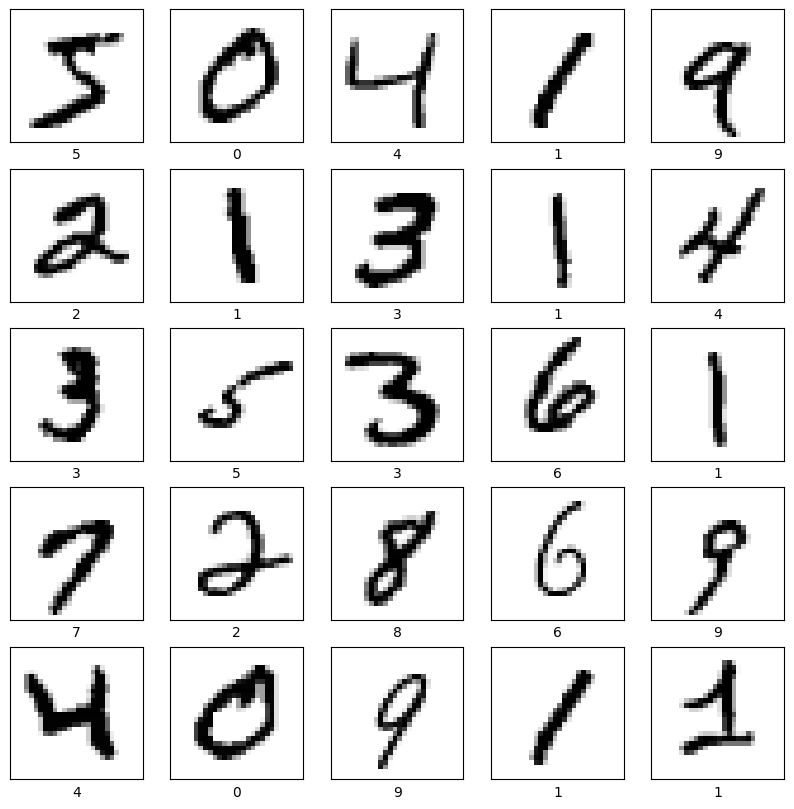

In [ ]:
# visualize some of the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

### Preprocessing data for MLP

In [ ]:

# Normalize pixel values to 0–1
X_train_norm = X_train / 255.0   # scale pixel values from 0–255 → 0–1
X_test_norm = X_test / 255.0     # apply same scaling to test data

# Flatten images for the MLP
X_train_flat = X_train_norm.reshape(X_train.shape[0], -1)  # # reshape from (60000, 28, 28) → (60000, 784)
X_test_flat = X_test_norm.reshape(X_test.shape[0], -1)     # same transformation for test images

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


### Building the MLP model

In [ ]:
# Define the MLP baseline model
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),                 # input is a flattened image (784 pixels)
    layers.Dense(128, activation="relu"),       # hidden layer with 128 neurons (learns patterns)
    layers.Dense(64, activation="relu"),        # second hidden layer for more complex patterns
    layers.Dense(10, activation="softmax"),     # output layer (10 classes for digits 0–9)
])

# Compile the MLP model
mlp_model.compile(
    optimizer="adam",                           # optimization algorithm for training
    loss="sparse_categorical_crossentropy",     # loss for multi-class classification with integer labels
    metrics=["accuracy"]                        # track accuracy during training
)

# summary of the MLP model architecture
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train the MLP model
history_mlp = mlp_model.fit(
    X_train_flat,                               # flattened training images
    y_train,                                    # labels (0–9)
    epochs=5,                                   # number of training passes through data
    batch_size=128,                             # number of samples per training step
    validation_split=0.1                        # use 10% of training data for validation
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(X_test_flat, y_test, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9004 - loss: 0.3570 - val_accuracy: 0.9580 - val_loss: 0.1465
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9565 - loss: 0.1478 - val_accuracy: 0.9653 - val_loss: 0.1149
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9696 - loss: 0.1016 - val_accuracy: 0.9747 - val_loss: 0.0884
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9776 - loss: 0.0758 - val_accuracy: 0.9747 - val_loss: 0.0864
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9813 - loss: 0.0602 - val_accuracy: 0.9780 - val_loss: 0.0746
313/313 - 1s - 3ms/step - accuracy: 0.9744 - loss: 0.0846
MLP Test accuracy: 0.9744


### Preparing data for CNN

In [ ]:
X_train_cnn = X_train_norm[..., np.newaxis]  # add channel dimension → (60000, 28, 28, 1)
X_test_cnn = X_test_norm[..., np.newaxis]    # same for test data

print("CNN input shape:", X_train_cnn.shape)  # confirm new shape for CNN

CNN input shape: (60000, 28, 28, 1)


### Building the CNN model

In [ ]:
# define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

In [ ]:
# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train_cnn,                                  # image data with spatial structure
    y_train,                                      # labels (correct digits)
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9445 - loss: 0.1851 - val_accuracy: 0.9798 - val_loss: 0.0723
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9817 - loss: 0.0623 - val_accuracy: 0.9837 - val_loss: 0.0585
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9875 - loss: 0.0417 - val_accuracy: 0.9855 - val_loss: 0.0491
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.9907 - loss: 0.0297 - val_accuracy: 0.9873 - val_loss: 0.0453
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9935 - loss: 0.0213 - val_accuracy: 0.9872 - val_loss: 0.0491


### Evaluating the CNN model

In [ ]:
# Evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)  # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9865 - loss: 0.0383
CNN Test Accuracy: 0.9865000247955322


### MLP vs CNN model

In [ ]:
# Compare the CNN's performance to the MLP baseline
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")
print(f"CNN Test accuracy: {cnn_acc:.4f}")


MLP Test accuracy: 0.9744
CNN Test accuracy: 0.9865


### Visualizing model training

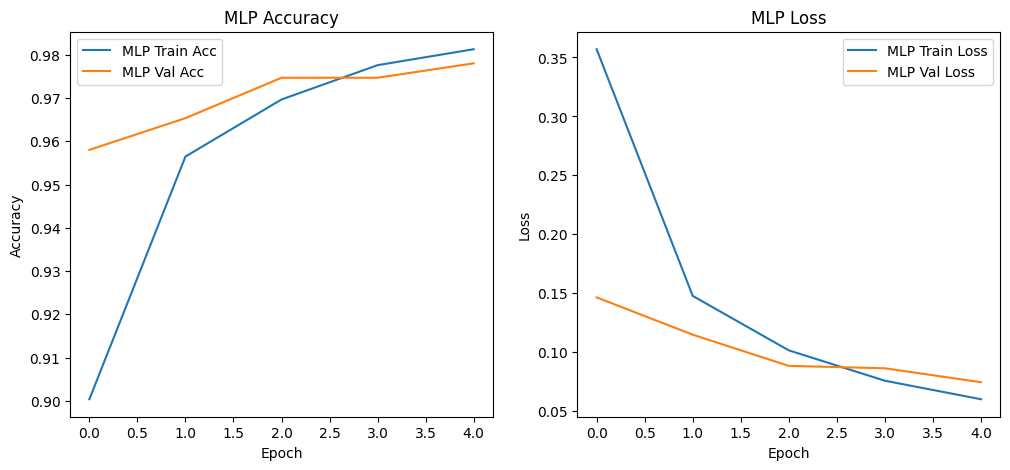

In [ ]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label='MLP Train Acc')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label='MLP Train Loss')
plt.plot(history_mlp.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


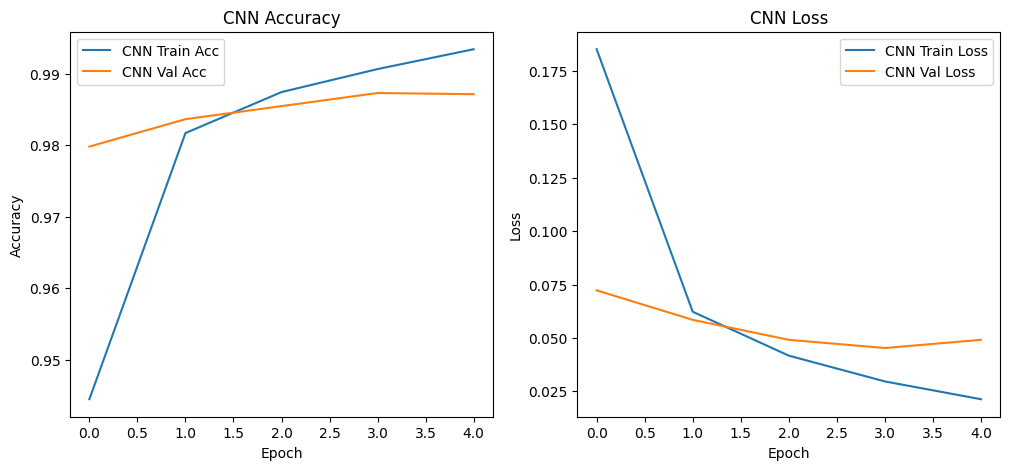

In [ ]:
# plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


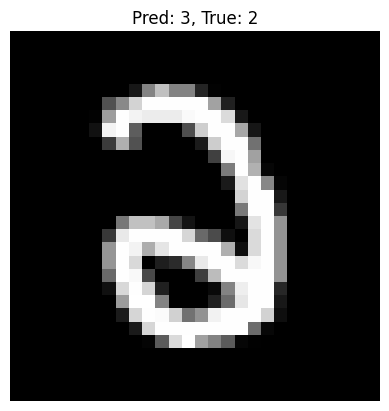

In [ ]:
# Get predictions
cnn_predictions = cnn_model.predict(X_test_cnn)

# Find a misclassified example
for i in range(len(X_test)):
    pred = np.argmax(cnn_predictions[i])  # predicted class

    if pred != y_test[i]:                 # compare to true label
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {pred}, True: {y_test[i]}")
        plt.axis("off")
        break

### How well do the models perform if we rotate the images?

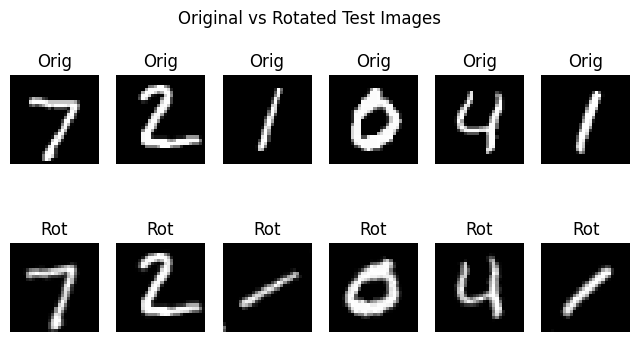

In [ ]:
# Visualize rotated test images (to see what changed)

rotation_layer_eval = tf.keras.layers.RandomRotation(0.15)

X_test_rot_eval_cnn = rotation_layer_eval(X_test_cnn, training=True)

plt.figure(figsize=(8, 4))

for i in range(6):
    # Original
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Orig")
    plt.axis('off')

    # Rotated
    plt.subplot(2, 6, i + 7)
    plt.imshow(X_test_rot_eval_cnn[i].numpy().squeeze(), cmap='gray')
    plt.title("Rot")
    plt.axis('off')

plt.suptitle("Original vs Rotated Test Images")
plt.show()

In [ ]:
# Flatten rotated images for MLP
X_test_rot_eval_flat = X_test_rot_eval_cnn.numpy().reshape(X_test.shape[0], -1)

# Evaluate original models on rotated data
mlp_rot_eval_loss, mlp_rot_eval_acc = mlp_model.evaluate(X_test_rot_eval_flat, y_test)
cnn_rot_eval_loss, cnn_rot_eval_acc = cnn_model.evaluate(X_test_rot_eval_cnn, y_test)

print("MLP accuracy (original test):", test_acc_mlp)
print("MLP accuracy (rotated test):", mlp_rot_eval_acc)

print("CNN accuracy (original test):", cnn_acc)
print("CNN accuracy (rotated test):", cnn_rot_eval_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7054 - loss: 1.4539
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7677 - loss: 1.1659
MLP accuracy (original test): 0.974399983882904
MLP accuracy (rotated test): 0.7053999900817871
CNN accuracy (original test): 0.9865000247955322
CNN accuracy (rotated test): 0.7677000164985657


### New models trained with data augmentation (random rotations)

In [ ]:
# Create rotated datasets for retraining models
rotation_layer_train = tf.keras.layers.RandomRotation(0.15)

X_train_rot_train_cnn = rotation_layer_train(X_train_cnn, training=True)  # rotated training images for CNN
X_test_rot_train_cnn = rotation_layer_train(X_test_cnn, training=True)    # rotated test images for CNN

# Flatten rotated datasets for MLP
X_train_rot_train_flat = X_train_rot_train_cnn.numpy().reshape(X_train.shape[0], -1)
X_test_rot_train_flat = X_test_rot_train_cnn.numpy().reshape(X_test.shape[0], -1)

### Use the code cell below to build, train and evaluate an MLP model using the rotated data (X_train_rot_train_flat and X_test_rot_train_flat)

In [ ]:
# Your code here

mlp_rot_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

mlp_rot_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mlp_rot_model.summary()

history_mlp_rot = mlp_rot_model.fit(
    X_train_rot_train_flat,                     # rotated + flattened training images
    y_train,                                    # labels (0–9)
    epochs=5,                                   # number of training passes
    batch_size=128,                             # samples per training step
    validation_split=0.1                        # 10% of training data for validation
)

rot_test_loss_mlp, rot_test_acc_mlp = mlp_rot_model.evaluate(X_test_rot_train_flat, y_test, verbose=2)
print(f"MLP (Rotated) Test Accuracy: {rot_test_acc_mlp:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8208 - loss: 0.5966 - val_accuracy: 0.9123 - val_loss: 0.2892
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9149 - loss: 0.2826 - val_accuracy: 0.9422 - val_loss: 0.1977
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9364 - loss: 0.2097 - val_accuracy: 0.9467 - val_loss: 0.1759
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9487 - loss: 0.1683 - val_accuracy: 0.9507 - val_loss: 0.1603
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9574 - loss: 0.1413 - val_accuracy: 0.9565 - val_loss: 0.1482
313/313 - 1s - 2ms/step - accuracy: 0.9454 - loss: 0.1783
MLP (Rotated) Test Accuracy: 0.9454


### Use the code cell below to build, train and evaluate a CNN model using the rotated data (X_train_rot_train_cnn and X_test_rot_train_cnn)

In [ ]:
# your code here

cnn_rot_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

cnn_rot_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_rot_history = cnn_rot_model.fit(
    X_train_rot_train_cnn,                      # rotated training images with channel dim
    y_train,                                    # labels (correct digits)
    epochs=5,                                   # number of passes through dataset
    validation_split=0.1                        # 10% for validation
)

cnn_rot_loss, cnn_rot_acc = cnn_rot_model.evaluate(X_test_rot_train_cnn, y_test)
print(f"CNN (Rotated) Test Accuracy: {cnn_rot_acc:.4f}")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.8910 - loss: 0.3528 - val_accuracy: 0.9530 - val_loss: 0.1551
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9559 - loss: 0.1438 - val_accuracy: 0.9677 - val_loss: 0.1117
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.9679 - loss: 0.1020 - val_accuracy: 0.9718 - val_loss: 0.0964
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.9756 - loss: 0.0769 - val_accuracy: 0.9757 - val_loss: 0.0858
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9814 - loss: 0.0585 - val_accuracy: 0.9755 - val_loss: 0.0906
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9681 - loss: 0.1001
CNN (Rotated) Test Accuracy: 0.9681


### Using the markdown cell below evaluate the performance of the MLP vs the CNN. Use graphs and metrics to support your evaluation.

MLP (Original) Test Accuracy:     0.9744
CNN (Original) Test Accuracy:     0.9865
MLP (Rot-Trained) Test Accuracy:  0.9454
CNN (Rot-Trained) Test Accuracy:  0.9681


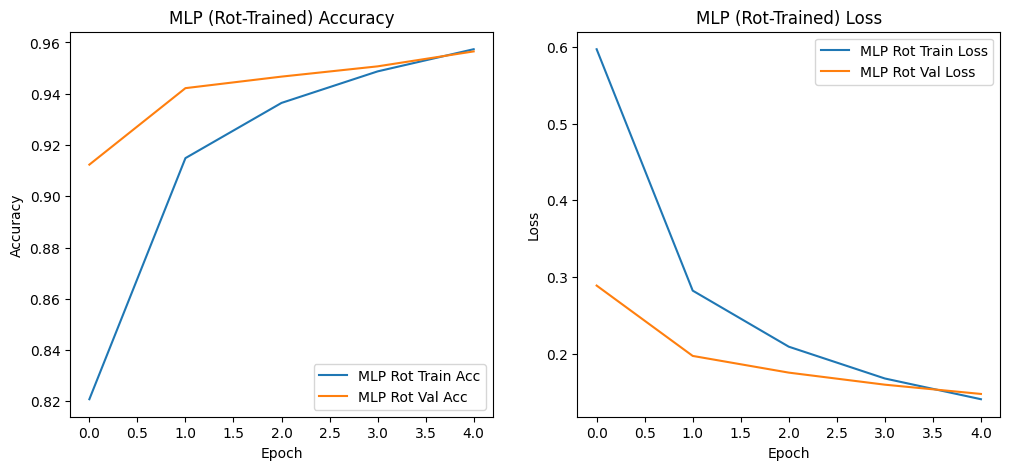

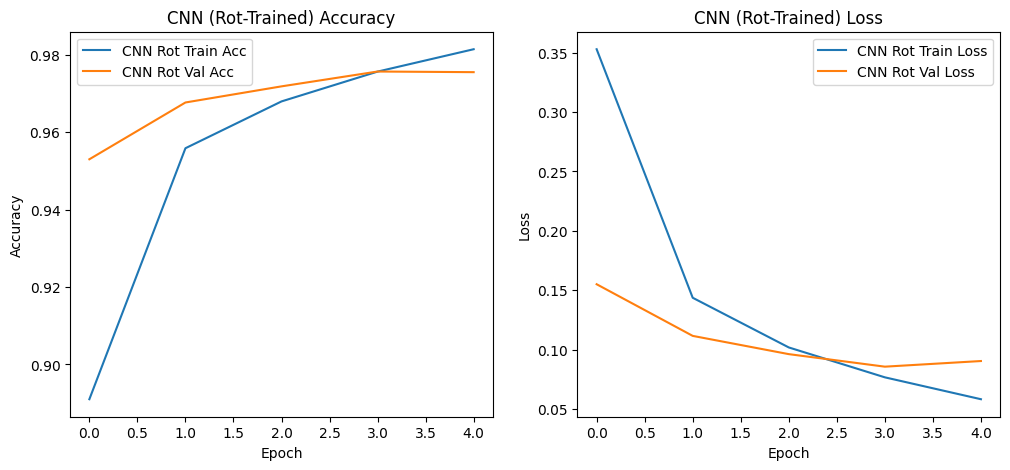

In [ ]:
# Compare all four models
print(f"MLP (Original) Test Accuracy:     {test_acc_mlp:.4f}")
print(f"CNN (Original) Test Accuracy:     {cnn_acc:.4f}")
print(f"MLP (Rot-Trained) Test Accuracy:  {rot_test_acc_mlp:.4f}")
print(f"CNN (Rot-Trained) Test Accuracy:  {cnn_rot_acc:.4f}")

# Plot training history for rotated MLP
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp_rot.history['accuracy'], label='MLP Rot Train Acc')
plt.plot(history_mlp_rot.history['val_accuracy'], label='MLP Rot Val Acc')
plt.title('MLP (Rot-Trained) Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp_rot.history['loss'], label='MLP Rot Train Loss')
plt.plot(history_mlp_rot.history['val_loss'], label='MLP Rot Val Loss')
plt.title('MLP (Rot-Trained) Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training history for rotated CNN
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_rot_history.history['accuracy'], label='CNN Rot Train Acc')
plt.plot(cnn_rot_history.history['val_accuracy'], label='CNN Rot Val Acc')
plt.title('CNN (Rot-Trained) Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_rot_history.history['loss'], label='CNN Rot Train Loss')
plt.plot(cnn_rot_history.history['val_loss'], label='CNN Rot Val Loss')
plt.title('CNN (Rot-Trained) Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Evaluation: MLP vs CNN on Rotated MNIST

### Accuracy Summary

| Model | Clean Test Accuracy | Rotated Test Accuracy |
|---|---|---|
| MLP (Original) | 0.9744 | lower (not rotation-robust) |
| CNN (Original) | 0.9865 | lower (not rotation-robust) |
| MLP (Rot-Trained) | — | 0.9454 |
| CNN (Rot-Trained) | — | 0.9681 |

(I didn't test Rot Trained models on Clean Test Acccuracy)

### Key Takeaways

**CNN outperforms MLP in both settings.** The CNN (Rot-Trained) achieved 96.81% accuracy on
rotated images compared to the MLP's 94.54% — a gap of ~2.3%. On clean data the CNN also led
(98.65% vs 97.44%). CNNs are better suited for image tasks because their  filters
detect local patterns like edges regardless of where they appear in the image, giving them a
natural advantage when images are rotated or shifted.

**Data augmentation helps both models.** Training on rotated images allowed both models to
generalize to rotation. Without augmentation, both models were only trained on upright digits
and struggled when test images were rotated.

**MLP training curves show a slow start.** As seen in the accuracy plot, the MLP's training
accuracy started at 0.82 and lagged behind validation accuracy for the first two epochs before
catching up by epoch 4. This suggests the MLP took longer to learn useful patterns from the
rotated data. The loss curves confirm steady convergence with no overfitting.

**Conclusion:** For image classification, CNNs are the stronger architecture — especially when
images may appear in different orientations. Data augmentation is a simple and effective way to
make both models more robust to real-world variation.